# 06 - Global Indie Hubs

**Question:** Are certain cities specialised in specific sounds — and is the
answer still the one everybody assumes?

Bristol and trip-hop, Detroit and techno, Nashville and country: music writing
runs on these associations. This dataset can test them, because every article
carries the record label's self-reported location.

**What's being measured, precisely:** the label's location, not the artist's.
Those diverge — an artist in Lagos signed to a Berlin label registers as
Berlin. That makes this a map of *where the infrastructure is*, which is
arguably the more interesting question, but it is not a map of where musicians
live. Worth stating before anyone reads a conclusion off it.

In [1]:
import sys
from pathlib import Path

# Make the pipeline package importable without installing it, so the notebook
# runs on a fresh clone. `pip install -e .` also works and is preferred.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from bandcamp_aotd.logging_config import setup_logging

setup_logging()

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

from bandcamp_aotd import config

sns.set_theme(style="whitegrid")
ACCENT = "#629aa9"

df = pd.read_csv(config.ANALYTICS_CSV, parse_dates=["published_date"])
located = df[df["country"].notna()].copy()

print(f"{len(located):,} of {len(df):,} features have a resolved location "
      f"({len(located) / len(df):.1%})")
print(f"{located['country'].nunique()} countries | {located['city'].nunique()} cities")

2,207 of 2,287 features have a resolved location (96.5%)
80 countries | 317 cities


## 1. The global picture

Concentration first, because it frames everything else.

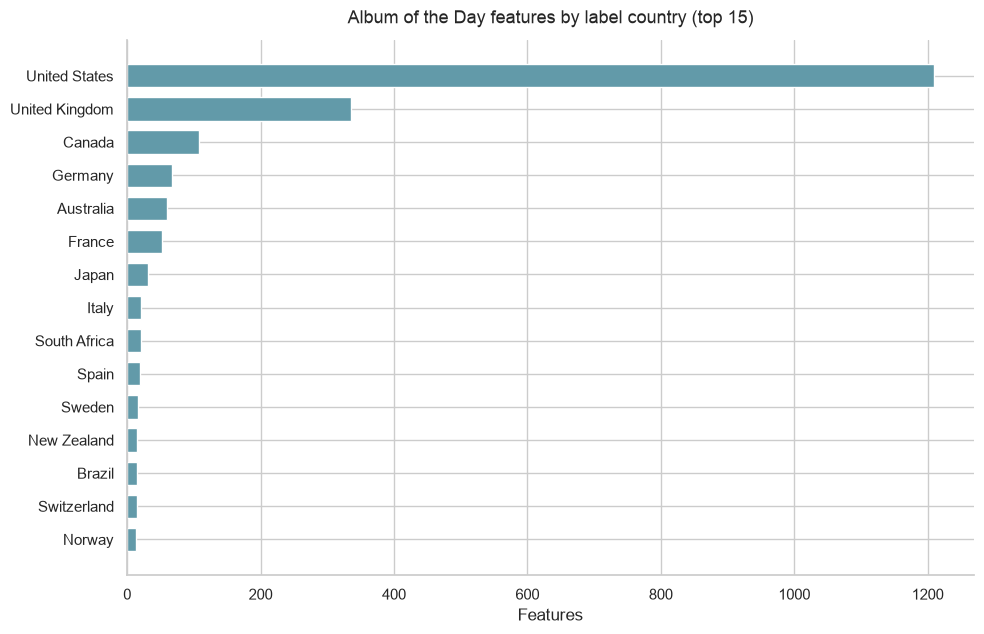

United States : 54.8%
Top 3         : 74.9%
Top 10        : 87.0%

The remaining 70 countries share 13.0% of all coverage.


In [3]:
country_counts = located["country"].value_counts()
share = country_counts / country_counts.sum()

fig, ax = plt.subplots(figsize=(10, 6.5))
top = country_counts.head(15)
ax.barh(top.index[::-1], top.values[::-1], color=ACCENT, height=0.7)
ax.set_title("Album of the Day features by label country (top 15)", fontsize=13, pad=12)
ax.set_xlabel("Features")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"United States : {share.iloc[0]:.1%}")
print(f"Top 3         : {share.head(3).sum():.1%}")
print(f"Top 10        : {share.head(10).sum():.1%}")
print(f"\nThe remaining {len(country_counts) - 10} countries share "
      f"{1 - share.head(10).sum():.1%} of all coverage.")

### Has that concentration changed over time?

A section that broadened its geographic reach would show a falling US share.
This is the more useful version of the previous chart — a single number moving
over fifteen years, rather than a static ranking.

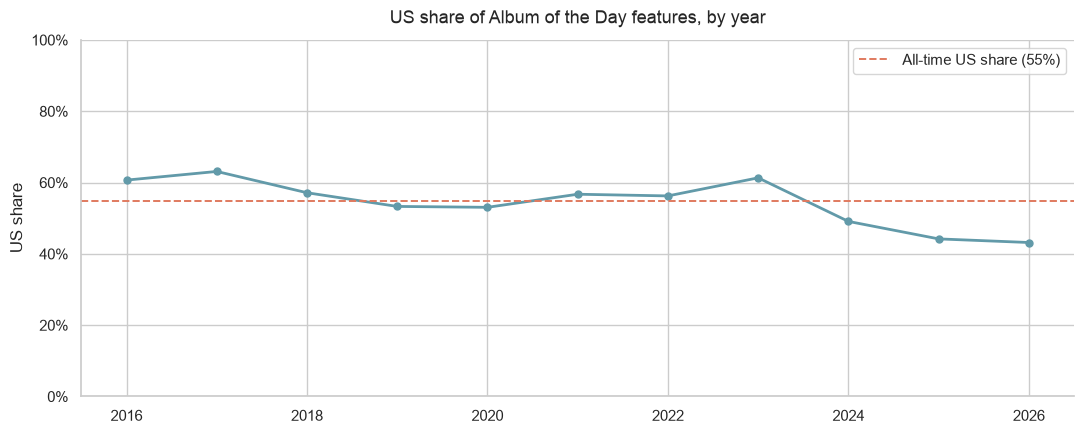

,mean,size
published_date,,
2016,0.607,117
2017,0.631,225
2018,0.571,224
2019,0.533,212
2020,0.531,213
2021,0.567,238
2022,0.562,224
2023,0.613,212
2024,0.491,222


In [4]:
us_share = (
    located.assign(is_us=located["country"].eq("United States"))
    .groupby(located["published_date"].dt.year)["is_us"]
    .agg(["mean", "size"])
)
us_share = us_share[us_share["size"] >= 20]      # drop thin years

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(us_share.index, us_share["mean"], marker="o", color=ACCENT,
        linewidth=2, markersize=5)
ax.axhline(share.iloc[0], color="#e07a5f", linestyle="--", linewidth=1.4,
           label=f"All-time US share ({share.iloc[0]:.0%})")
ax.set_title("US share of Album of the Day features, by year", fontsize=13, pad=12)
ax.set_ylabel("US share")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

us_share.round(3)

### Was 2024 a change of writers?

The share sat between 53% and 61% from 2018 to 2023, then fell 12 points in a
single year. A step like that invites the obvious explanation: different
people started writing. If so, writers active both before and after 2024
should look the same as they always did, and the drop should come from
newcomers. Test it directly.

In [5]:
from scipy.stats import chi2_contingency

before = located[located["year"].between(2018, 2023)]
after = located[located["year"] >= 2024]
continuing = set(before["author"].dropna()) & set(after["author"].dropna())

since_2024 = df[df["year"] >= 2024]
print(f"{since_2024['author'].isin(continuing).mean():.0%} of features since 2024 "
      f"were written by the {len(continuing)} writers also active in 2018-23")

b = before[before["author"].isin(continuing)]["country"].eq("United States")
a = after[after["author"].isin(continuing)]["country"].eq("United States")
newcomers = after[~after["author"].isin(continuing)]["country"].eq("United States")

print(f"Continuing writers, US share 2018-23: {b.mean():.1%}  (n={len(b)})")
print(f"Continuing writers, US share 2024+:   {a.mean():.1%}  (n={len(a)})")
print(f"Newer writers,      US share 2024+:   {newcomers.mean():.1%}  (n={len(newcomers)})")

table = [[b.sum(), (~b).sum()], [a.sum(), (~a).sum()]]
chi2, p, _, _ = chi2_contingency(table)
print(f"\nChi-square, continuing writers before vs after: chi2={chi2:.2f}, p={p:.3f}")

73% of features since 2024 were written by the 53 writers also active in 2018-23
Continuing writers, US share 2018-23: 53.6%  (n=599)
Continuing writers, US share 2024+:   45.8%  (n=391)
Newer writers,      US share 2024+:   46.9%  (n=143)

Chi-square, continuing writers before vs after: chi2=5.46, p=0.019


The same writers moved. Their US share fell by about eight points, and the
change is unlikely to be noise; newer writers sit at a similar level. The
shift happened *within* the existing roster, which points to commissioning or
submissions rather than personnel. The timing coincides with Bandcamp's sale
to Songtradr in late 2023, but observational data can't establish cause.

## 2. Which cities are specialised?

**Lift** is the metric: a genre's share *within* a city divided by that
genre's share across the whole archive.

- lift = 1 → the city looks exactly like the archive average
- lift = 5 → that genre is five times as prevalent there as everywhere else

Lift is badly behaved in the tail. A city with 12 features and one children's
record scores a lift of 66 and tops any unfiltered ranking, which means
nothing at all. Two floors keep it honest: **the city needs ≥ 10 features, and
the city/genre pair needs ≥ 3.** Raw counts are kept alongside the ratio so
the evidence is visible rather than taken on trust.

This is the same calculation as the `vw_city_genre_specialisation` view in
`db/views.sql` — defined once in SQL, reproduced here for the narrative.

In [6]:
MIN_CITY_FEATURES = 10
MIN_PAIR_FEATURES = 3

city_totals = located.groupby("city").size()
eligible = city_totals[city_totals >= MIN_CITY_FEATURES].index
global_share = located["genre_tag"].value_counts(normalize=True)

pairs = (
    located[located["city"].isin(eligible)]
    .groupby(["city", "country", "genre_tag"])
    .size()
    .reset_index(name="features")
)
pairs = pairs[pairs["features"] >= MIN_PAIR_FEATURES]
pairs["city_features"] = pairs["city"].map(city_totals)
pairs["city_share"] = pairs["features"] / pairs["city_features"]
pairs["global_share"] = pairs["genre_tag"].map(global_share)
pairs["lift"] = (pairs["city_share"] / pairs["global_share"]).round(2)

print(f"{len(eligible)} cities clear the {MIN_CITY_FEATURES}-feature floor")
pairs.sort_values("lift", ascending=False).head(15).reset_index(drop=True)

28 cities clear the 10-feature floor


,city,country,genre_tag,features,city_features,city_share,global_share,lift
0,Nashville,United States,Country,3,21,0.142857,0.007330,19.49
1,Pittsburgh,United States,Metal,11,15,0.733333,0.057068,12.85
2,Tokyo,Japan,Ambient,4,16,0.250000,0.035079,7.13
3,Austin,United States,Folk,3,19,0.157895,0.026702,5.91
4,Detroit,United States,Hip-Hop/Rap,11,29,0.379310,0.078534,4.83
5,Toronto,Canada,R&B/Soul,6,41,0.146341,0.036126,4.05
6,Kampala,Uganda,Electronic,7,12,0.583333,0.160209,3.64
7,Melbourne,Australia,Rock,9,35,0.257143,0.072251,3.56
8,Philadelphia,United States,Punk,6,34,0.176471,0.052880,3.34
9,Portland,United States,Metal,7,37,0.189189,0.057068,3.32


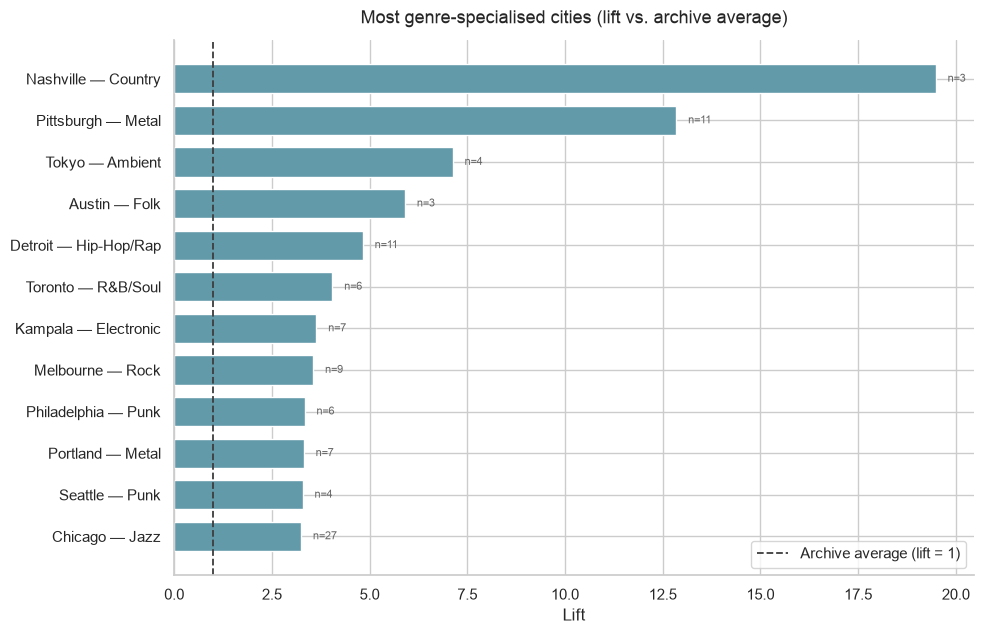

In [7]:
top_pairs = pairs.sort_values("lift", ascending=False).head(12)
labels = top_pairs["city"] + " — " + top_pairs["genre_tag"]

fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.barh(labels[::-1], top_pairs["lift"][::-1], color=ACCENT, height=0.7)
ax.axvline(1, color="#3d3d3d", linestyle="--", linewidth=1.3,
           label="Archive average (lift = 1)")
for bar, n in zip(bars, top_pairs["features"][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"n={n}", va="center", fontsize=8, color="#666")
ax.set_title("Most genre-specialised cities (lift vs. archive average)",
             fontsize=13, pad=12)
ax.set_xlabel("Lift")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Testing the received wisdom directly

The clichés, checked against the data rather than assumed.

In [8]:
CLAIMS = [
    ("Bristol", "Electronic"),
    ("Detroit", "Electronic"),
    ("Detroit", "Hip-Hop/Rap"),
    ("Nashville", "Country"),
    ("Berlin", "Electronic"),
    ("Chicago", "Hip-Hop/Rap"),
    ("Tokyo", "Ambient"),
]

rows = []
for city, genre in CLAIMS:
    subset = located[located["city"] == city]
    if subset.empty:
        rows.append({"City": city, "Genre": genre, "Verdict": "no data"})
        continue
    n = int((subset["genre_tag"] == genre).sum())
    city_share = n / len(subset)
    lift = city_share / global_share.get(genre, float("nan"))
    rows.append({
        "City": city,
        "Genre": genre,
        "City features": len(subset),
        f"{genre} features": n,
        "City share": f"{city_share:.0%}",
        "Lift": round(lift, 2),
        "Verdict": ("supported" if lift >= 2 and n >= 3
                    else "weak" if lift >= 1.2 and n >= 3
                    else "not supported"),
    })

pd.DataFrame(rows)

,City,Genre,City features,Electronic features,City share,Lift,Verdict,Hip-Hop/Rap features,Country features,Ambient features
0,Bristol,Electronic,11,5.0,45%,2.84,supported,NaN,NaN,NaN
1,Detroit,Electronic,29,5.0,17%,1.08,not supported,NaN,NaN,NaN
2,Detroit,Hip-Hop/Rap,29,NaN,38%,4.83,supported,11.0,NaN,NaN
3,Nashville,Country,21,NaN,14%,19.49,supported,NaN,3.0,NaN
4,Berlin,Electronic,45,20.0,44%,2.77,supported,NaN,NaN,NaN
5,Chicago,Hip-Hop/Rap,108,NaN,8%,1.06,not supported,9.0,NaN,NaN
6,Tokyo,Ambient,16,NaN,25%,7.13,supported,NaN,NaN,4.0


## 3. Independent share by country

Where do self-released records get featured most? Restricted to countries with
enough features for the proportion to mean anything.

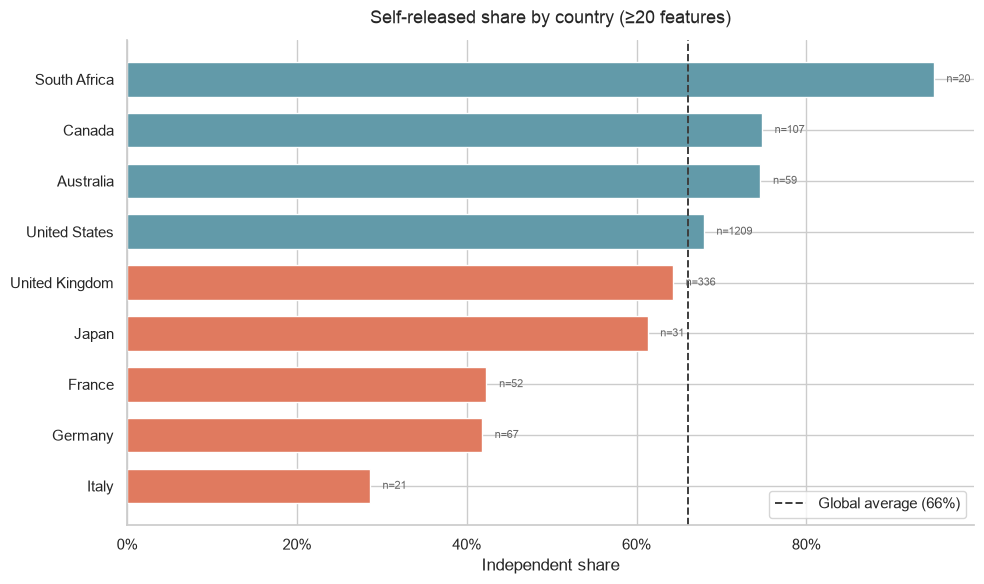

In [9]:
by_country = (
    located.groupby("country")
    .agg(features=("article_id", "size"), indie_share=("is_independent", "mean"))
    .query("features >= 20")
    .sort_values("indie_share")
)

fig, ax = plt.subplots(figsize=(10, 6))
baseline = located["is_independent"].mean()
colors = ["#e07a5f" if v < baseline else ACCENT for v in by_country["indie_share"]]
ax.barh(by_country.index, by_country["indie_share"], color=colors, height=0.68)
ax.axvline(baseline, color="#3d3d3d", linestyle="--", linewidth=1.4,
           label=f"Global average ({baseline:.0%})")
for i, (features, sharev) in enumerate(zip(by_country["features"], by_country["indie_share"])):
    ax.text(sharev + 0.015, i, f"n={features}", va="center", fontsize=8, color="#666")
ax.set_title("Self-released share by country (≥20 features)", fontsize=13, pad=12)
ax.set_xlabel("Independent share")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4. The choropleth aggregate

Tableau and the web app draw the map from `vw_coverage_by_country`. This
recomputes the same aggregate in pandas as a cross-check that the view and the
analysis agree. It deliberately writes nothing: the file Tableau reads,
`data/exports/coverage_by_country.csv`, has one producer
(`python -m bandcamp_aotd export --views`), so it always matches the view.

In [10]:
choropleth = (
    located.groupby("country")
    .agg(
        features=("article_id", "size"),
        distinct_artists=("artist", "nunique"),
        distinct_labels=("record_label", "nunique"),
        distinct_genres=("genre_tag", "nunique"),
        indie_share=("is_independent", "mean"),
        first_feature=("published_date", "min"),
        latest_feature=("published_date", "max"),
    )
    .reset_index()
    .sort_values("features", ascending=False)
)
choropleth["pct_of_all_features"] = (choropleth["features"] / choropleth["features"].sum() * 100).round(2)

print(f"{len(choropleth)} countries")
choropleth.head(10)

80 countries


,country,features,distinct_artists,distinct_labels,distinct_genres,indie_share,first_feature,latest_feature,pct_of_all_features
75,United States,1209,1055,293,23,0.679074,2011-10-28,2026-05-26,54.78
74,United Kingdom,336,285,95,18,0.642857,2011-11-21,2026-05-22,15.22
9,Canada,107,97,26,14,0.747664,2011-11-27,2026-05-18,4.85
23,Germany,67,61,27,14,0.417910,2016-06-20,2026-03-12,3.04
3,Australia,59,53,15,12,0.745763,2016-06-30,2026-04-24,2.67
21,France,52,45,17,13,0.423077,2016-06-28,2025-12-05,2.36
37,Japan,31,30,12,11,0.612903,2017-08-17,2026-05-01,1.40
35,Italy,21,18,10,8,0.285714,2017-01-05,2026-04-09,0.95
62,South Africa,20,15,2,6,0.950000,2018-10-11,2026-05-11,0.91
64,Spain,19,16,6,8,0.684211,2017-10-31,2025-11-04,0.86


## Findings

**Coverage is heavily concentrated.** Over half of everything Bandcamp Daily
features comes from US-based labels, and the top three countries account for
roughly three quarters. Whether that reflects editorial preference or simply
where Bandcamp's label base sits cannot be settled from this data alone — it
would need Bandcamp's own catalogue as a denominator, which isn't public.

**City specialisation is real but narrower than the clichés suggest.** A
handful of city/genre pairs clear a meaningful lift threshold with enough
features to be credible. Many of the famous associations don't survive the
count floor — not because they're false, but because the archive simply
doesn't contain enough features from those cities to say.

**The measurement caveat is the finding, partly.** Label location is a proxy
for artist location, and a lossy one. Any conclusion here is about where the
*infrastructure* of independent music sits, not where the musicians are.

### Where this goes next

- **Geocode `dim_place`** (the `latitude` / `longitude` columns already exist)
  to move from country choropleth to city-level point mapping.
- **Add artist location** — Bandcamp artist pages carry it — and measure the
  label-to-artist distance directly. Do labels sign locally, or is independent
  music genuinely borderless? That's the question this dataset is closest to
  answering and doesn't yet.